In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

# Load the transaction data (notebook is in notebooks/ folder)
df = pd.read_csv('../data/data.csv')

print("="*60)
print("DATA LOADED")
print("="*60)
print(f"Shape: {df.shape[0]:,} rows, {df.shape[1]} columns")
df.head()

DATA LOADED
Shape: 95,662 rows, 16 columns


,TransactionId,BatchId,AccountId,SubscriptionId,CustomerId,CurrencyCode,CountryCode,ProviderId,ProductId,ProductCategory,ChannelId,Amount,Value,TransactionStartTime,PricingStrategy,FraudResult
0,TransactionId_76871,BatchId_36123,AccountId_3957,SubscriptionId_887,CustomerId_4406,UGX,256,ProviderId_6,ProductId_10,airtime,ChannelId_3,1000.0,1000,2018-11-15T02:18:49Z,2,0
1,TransactionId_73770,BatchId_15642,AccountId_4841,SubscriptionId_3829,CustomerId_4406,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-20.0,20,2018-11-15T02:19:08Z,2,0
2,TransactionId_26203,BatchId_53941,AccountId_4229,SubscriptionId_222,CustomerId_4683,UGX,256,ProviderId_6,ProductId_1,airtime,ChannelId_3,500.0,500,2018-11-15T02:44:21Z,2,0
3,TransactionId_380,BatchId_102363,AccountId_648,SubscriptionId_2185,CustomerId_988,UGX,256,ProviderId_1,ProductId_21,utility_bill,ChannelId_3,20000.0,21800,2018-11-15T03:32:55Z,2,0
4,TransactionId_28195,BatchId_38780,AccountId_4841,SubscriptionId_3829,CustomerId_988,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-644.0,644,2018-11-15T03:34:21Z,2,0


In [3]:
# Convert TransactionStartTime to datetime
df['TransactionStartTime'] = pd.to_datetime(df['TransactionStartTime'])

print(f"Date range: {df['TransactionStartTime'].min()} to {df['TransactionStartTime'].max()}")
print(f"Total customers: {df['CustomerId'].nunique():,}")

Date range: 2018-11-15 02:18:49+00:00 to 2019-02-13 10:01:28+00:00
Total customers: 3,742


In [4]:
# Define snapshot date (day after last transaction)
snapshot_date = df['TransactionStartTime'].max() + pd.Timedelta(days=1)

# Group by CustomerId
rfm = df.groupby('CustomerId').agg({
    'TransactionStartTime': lambda x: (snapshot_date - x.max()).days,  # Recency
    'TransactionId': 'count',                                          # Frequency
    'Amount': 'sum'                                                    # Monetary
}).rename(columns={
    'TransactionStartTime': 'Recency',
    'TransactionId': 'Frequency',
    'Amount': 'Monetary'
})

print("RFM table shape:", rfm.shape)
rfm.head()

RFM table shape: (3742, 3)


,Recency,Frequency,Monetary
CustomerId,,,
CustomerId_1,84,1,-10000.0
CustomerId_10,84,1,-10000.0
CustomerId_1001,90,5,20000.0
CustomerId_1002,26,11,4225.0
CustomerId_1003,12,6,20000.0


In [5]:
# Keep only positive Monetary values
rfm = rfm[rfm['Monetary'] > 0]

# Check for any infinite or missing values
print(f"Rows after removing zero/negative Monetary: {len(rfm)}")
print(f"Missing values:\n{rfm.isnull().sum()}")

Rows after removing zero/negative Monetary: 3543
Missing values:
Recency      0
Frequency    0
Monetary     0
dtype: int64


In [6]:
# Standardize the features (important for K-Means)
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])

print("Scaled RFM shape:", rfm_scaled.shape)
print("Mean after scaling (should be ~0):", rfm_scaled.mean(axis=0))
print("Std after scaling (should be ~1):", rfm_scaled.std(axis=0))

Scaled RFM shape: (3543, 3)
Mean after scaling (should be ~0): [-2.80767663e-17 -3.30904746e-17  2.00548331e-18]
Std after scaling (should be ~1): [1. 1. 1.]


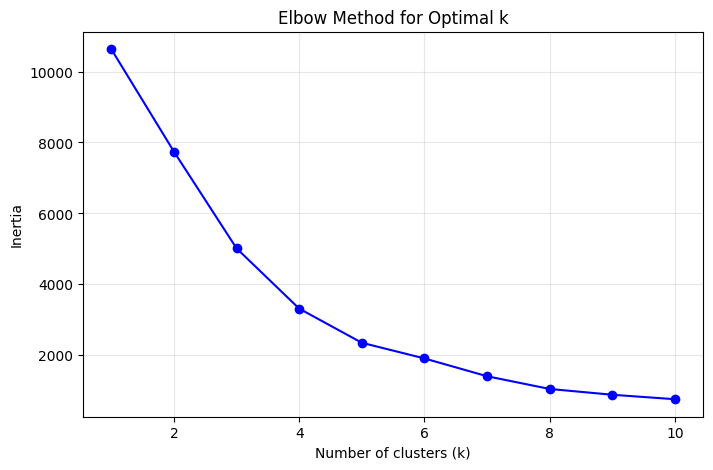

In [7]:
# Elbow method to choose k
inertias = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertias.append(kmeans.inertia_)

# Plot elbow curve
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertias, 'bo-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.grid(True, alpha=0.3)
plt.show()

Cluster counts:
Cluster
1    2163
0    1375
2       5
Name: count, dtype: int64


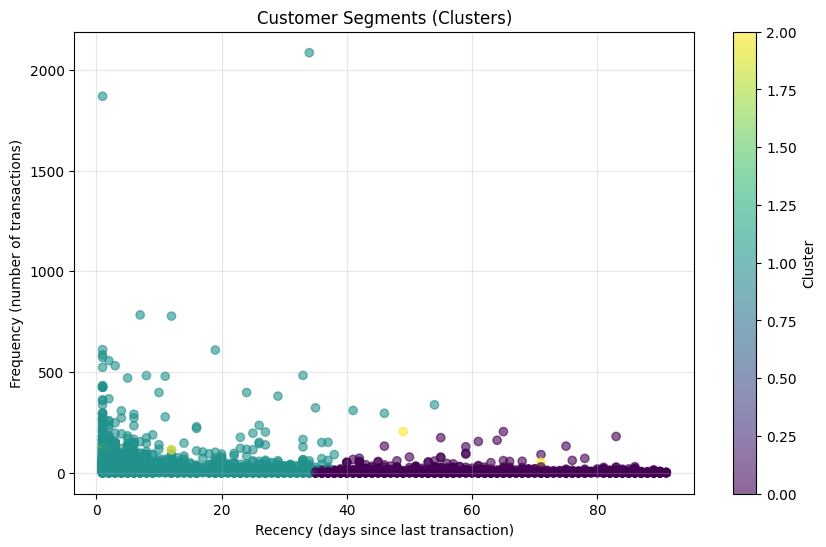

In [8]:
# Choose k based on elbow plot (usually 3 or 4)
k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

print("Cluster counts:")
print(rfm['Cluster'].value_counts())

# Visualize clusters (Recency vs Frequency)
plt.figure(figsize=(10, 6))
scatter = plt.scatter(rfm['Recency'], rfm['Frequency'], c=rfm['Cluster'], cmap='viridis', alpha=0.6)
plt.xlabel('Recency (days since last transaction)')
plt.ylabel('Frequency (number of transactions)')
plt.title('Customer Segments (Clusters)')
plt.colorbar(scatter, label='Cluster')
plt.grid(True, alpha=0.3)
plt.show()

In [9]:
# Analyze cluster characteristics
cluster_summary = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean'
}).round(2)

print("Cluster characteristics:")
print(cluster_summary)

# The "high-risk" cluster is the one with HIGH Recency and LOW Frequency/Monetary
# Identify it manually based on the numbers
# Usually it's the cluster with highest average Recency and lowest Frequency

# Let's find which cluster has highest Recency (least recent)
high_risk_cluster = cluster_summary['Recency'].idxmax()
print(f"\nHigh-risk cluster (disengaged customers): Cluster {high_risk_cluster}")

# Create the proxy target variable
rfm['is_high_risk'] = (rfm['Cluster'] == high_risk_cluster).astype(int)

print("\nProxy target distribution:")
print(rfm['is_high_risk'].value_counts())
print(f"Percentage high-risk: {rfm['is_high_risk'].mean()*100:.1f}%")

Cluster characteristics:
         Recency  Frequency     Monetary
Cluster                                 
0          60.78       7.66     68321.27
1          12.08      36.84    189998.75
2          27.20     100.40  50697885.60

High-risk cluster (disengaged customers): Cluster 0

Proxy target distribution:
is_high_risk
0    2168
1    1375
Name: count, dtype: int64
Percentage high-risk: 38.8%


In [10]:
# Keep only needed columns for modeling
customer_risk = rfm[['is_high_risk']].reset_index()

# Merge with original transaction data? 
# For modeling, we usually create a customer-level dataset.
# We'll create a customer-level feature set.

# First, aggregate transaction features per customer
customer_features = df.groupby('CustomerId').agg({
    'Amount': ['mean', 'std', 'sum', 'count'],
    'ProductCategory': lambda x: x.mode()[0] if len(x.mode()) > 0 else 'Unknown',
    'ChannelId': lambda x: x.mode()[0] if len(x.mode()) > 0 else 'Unknown',
}).reset_index()

# Flatten column names
customer_features.columns = ['CustomerId', 'Amount_Mean', 'Amount_Std', 'Amount_Sum', 'Transaction_Count', 'Top_ProductCategory', 'Top_ChannelId']

# Merge with risk label
customer_features = customer_features.merge(customer_risk, on='CustomerId', how='inner')

print("Customer-level dataset shape:", customer_features.shape)
customer_features.head()

Customer-level dataset shape: (3543, 8)


,CustomerId,Amount_Mean,Amount_Std,Amount_Sum,Transaction_Count,Top_ProductCategory,Top_ChannelId,is_high_risk
0,CustomerId_1001,4000.000000,6558.963333,20000.0,5,financial_services,ChannelId_3,1
1,CustomerId_1002,384.090909,560.498966,4225.0,11,financial_services,ChannelId_2,0
2,CustomerId_1003,3333.333333,6030.478146,20000.0,6,airtime,ChannelId_3,0
3,CustomerId_1004,2000.000000,NaN,2000.0,1,airtime,ChannelId_3,1
4,CustomerId_1005,5422.222222,5983.681513,48800.0,9,financial_services,ChannelId_3,1


In [11]:
# Save to data folder
customer_features.to_csv('../data/customer_features_with_risk.csv', index=False)
print("✅ Saved: ../data/customer_features_with_risk.csv")
print(f"Dataset has {customer_features.shape[0]} customers and {customer_features.shape[1]} features.")

✅ Saved: ../data/customer_features_with_risk.csv
Dataset has 3543 customers and 8 features.
